### Loading data

In [1]:
import pandas as pd


In [2]:
Parking_space = pd.read_csv('C:/Users/anton/Downloads/Parking_Meters_20260315.csv')
Parking_space.sample(5)

,OBJECTID,PARKING_SPACE_ID,POST_ID,MS_PAY_STATION_ID,MS_SPACE_NUM,SENSOR_FLAG,ON_OFFSTREET_TYPE,OSP_ID,JURISDICTION,PM_DISTRICT_ID,...,PMR_ROUTE,NFC_KEY,SPT_CODE,COLLECTION_ROUTE_DESC,COLLECTION_SUBROUTE_DESC,shape,data_as_of,data_loaded_at,analysis_neighborhood,supervisor_district
4046,11015917,NaN,116-04020,-,0,NaN,ON,NaN,SFMTA,21.0,...,B-3,NaN,NaN,Geary St: 5000 - 5200,Geary,POINT (-122.475013498 37.7803496),2026 Mar 14 12:11:59 AM,2026 Mar 14 10:28:23 AM,Outer Richmond,1
8177,11025498,NaN,823-00360,-,0,NaN,ON,NaN,PORT,11.0,...,Port 1,NaN,NaN,Chestnut St; Mongomery St,Chestnut,POINT (-122.4049774 37.804840499),2026 Mar 14 12:11:59 AM,2026 Mar 14 10:28:23 AM,North Beach,3
22895,11009210,NaN,568-12230,-,0,NaN,ON,NaN,SFMTA,14.0,...,N-2,NaN,NaN,NaN,NaN,POINT (-122.413692601 37.7769278),2026 Mar 14 12:11:59 AM,2026 Mar 14 10:28:23 AM,South of Market,6
12281,10999988,NaN,620-01580,-,0,NaN,ON,NaN,SFMTA,2.0,...,M-3,NaN,NaN,NaN,NaN,POINT (-122.398330399 37.780993001),2026 Mar 14 12:11:59 AM,2026 Mar 14 10:28:23 AM,South of Market,6
32866,11006504,NaN,720-05820,720-05006,82,NaN,ON,NaN,SFMTA,1.0,...,G-2,NaN,NaN,Washington St: 200 - 400,"Washington St: 200, 300, 500",POINT (-122.403160511 37.795604673),2026 Mar 14 12:11:59 AM,2026 Mar 14 10:28:23 AM,Chinatown,3


In [3]:
Dispatches = pd.read_csv('C:/Users/anton/Downloads/Fire_Department_and_Emergency_Medical_Services_Dispatched_Calls_for_Service_20260315.csv').sample(frac=0.05)

In [4]:
Dispatches.sample(5)

,Call Type,Response DtTm,On Scene DtTm,Call Final Disposition,Address,Zipcode of Incident,Unit Type,Fire Prevention District,Supervisor District,Neighborhooods - Analysis Boundaries,Battalion
3529658,Medical Incident,2017 Mar 03 05:32:15 PM,2017 Mar 03 05:34:22 PM,Code 2 Transport,04TH ST/MINNA ST,94103.0,ENGINE,3.0,6.0,Financial District/South Beach,B03
4884292,Medical Incident,2015 Nov 21 05:03:36 PM,2015 Nov 21 05:05:03 PM,Unable to Locate,ALEMANY BLVD/INDUSTRIAL ST OFF RAMP/SAN BRUNO ...,94134.0,ENGINE,10.0,9.0,Portola,B10
4368345,Medical Incident,2020 Mar 27 09:19:07 AM,2020 Mar 27 09:25:14 AM,No Merit,STOCKTON ST/STOCKTON TUNL/SUTTER ST,94108.0,MEDIC,1.0,3.0,Financial District/South Beach,B01
1315095,Medical Incident,2023 Mar 05 08:25:16 PM,2023 Mar 05 08:29:52 PM,Code 2 Transport,EDDY ST/HYDE ST,94102.0,MEDIC,2.0,6.0,Tenderloin,B02
2669550,Medical Incident,2009 May 08 11:25:28 PM,2009 May 08 11:30:26 PM,Patient Declined Transport,TAYLOR ST/SACRAMENTO ST,94108.0,MEDIC,1.0,3.0,Nob Hill,B01


In [5]:
Dispatches.size

3001295

### Converting string dates into datetime format

In [6]:
Dispatches['On Scene DtTm']

4252072    2014 Jun 18 05:08:13 PM
1104425    2003 May 18 05:53:11 AM
2169613    2019 Jun 04 03:01:11 PM
4687266    2005 Feb 14 09:06:05 AM
3173259    2019 Jan 25 09:10:50 AM
                    ...           
1011977    2002 Sep 10 07:42:53 PM
53163      2016 Jun 19 02:10:27 AM
636850     2022 Mar 02 11:44:29 AM
624621     2022 Feb 16 06:12:04 PM
549115     2019 May 03 06:16:27 PM
Name: On Scene DtTm, Length: 272845, dtype: object

In [7]:
def daytime_to_minutes(x):
    return x.dt.hour * 60 + x.dt.minute + x.dt.second/60

In [8]:
time_cols = ['Response DtTm','On Scene DtTm']

In [9]:
Dispatches[time_cols] = Dispatches[time_cols].apply(lambda x: pd.to_datetime(x,format = '%Y %b %d %I:%M:%S %p')).apply(daytime_to_minutes)

In [10]:
Dispatches['On Scene DtTm']

4252072    1028.216667
1104425     353.183333
2169613     901.183333
4687266     546.083333
3173259     550.833333
              ...     
1011977    1182.883333
53163       130.450000
636850      704.483333
624621     1092.066667
549115     1096.450000
Name: On Scene DtTm, Length: 272845, dtype: float64

### Calculating time needed to reach destination after car received assignment

In [11]:
Dispatches["Time_in_transit"] = Dispatches['On Scene DtTm'] - Dispatches['Response DtTm']

In [12]:
Dispatches["Time_in_transit"]

4252072    0.750000
1104425    2.800000
2169613    5.466667
4687266    6.716667
3173259    4.900000
             ...   
1011977    1.833333
53163      1.866667
636850     7.700000
624621     6.566667
549115     1.833333
Name: Time_in_transit, Length: 272845, dtype: float64

### I wanted to see if number of parkings corelates with times needed to reach destination. So I'm counting number of parkings in neighborhood

In [13]:
Parking_space["Count"] = 1

In [14]:
Num_Parkings = Parking_space.groupby("analysis_neighborhood")["Count"].sum()
Num_Parkings

analysis_neighborhood
Bayview Hunters Point              263
Bernal Heights                     400
Castro/Upper Market                545
Chinatown                         1748
Excelsior                          285
Financial District/South Beach    6853
Glen Park                           65
Golden Gate Park                    10
Haight Ashbury                     381
Hayes Valley                      1637
Inner Richmond                     986
Inner Sunset                       545
Japantown                          524
Lakeshore                           91
Lone Mountain/USF                  133
Marina                             893
Mission                           3701
Mission Bay                       2296
Nob Hill                          1219
Noe Valley                         254
North Beach                       1329
Oceanview/Merced/Ingleside          61
Outer Mission                      304
Outer Richmond                     900
Pacific Heights                    608
Por

In [15]:
# Adding number of parkings to our main table
Dispatches = result = pd.merge(Dispatches, Num_Parkings, how="left", left_on = "Neighborhooods - Analysis Boundaries", right_on = "analysis_neighborhood")
Dispatches.sample(5)

,Call Type,Response DtTm,On Scene DtTm,Call Final Disposition,Address,Zipcode of Incident,Unit Type,Fire Prevention District,Supervisor District,Neighborhooods - Analysis Boundaries,Battalion,Time_in_transit,Count
28387,Medical Incident,769.650000,786.900000,Code 2 Transport,GEARY ST/POLK ST,94109.0,PRIVATE,4.0,6.0,Tenderloin,B04,17.250000,3039.0
84511,Medical Incident,361.283333,372.050000,Code 2 Transport,LEAVENWORTH ST/UNITED NATIONS PLZ,94102.0,PRIVATE,2.0,5.0,Tenderloin,B02,10.766667,3039.0
62956,Alarms,1230.516667,1232.300000,Fire,LAPIDGE ST/19TH ST,94110.0,TRUCK,6.0,8.0,Mission,B06,1.783333,3701.0
151193,Medical Incident,746.566667,749.083333,Other,45TH AVE/BALBOA ST,94121.0,ENGINE,7.0,1.0,Outer Richmond,B07,2.516667,900.0
41709,Traffic Collision,1130.066667,1138.750000,Other,FILLMORE ST/PAGE ST,94117.0,MEDIC,2.0,5.0,Hayes Valley,B05,8.683333,1637.0


In [16]:
Dispatches_Grouped = Dispatches.groupby("Neighborhooods - Analysis Boundaries",group_keys=True)

In [31]:
# calculating relative std
Dispatches_Grouped[["Time_in_transit"]].std() / Dispatches_Grouped[["Time_in_transit"]].mean()

,Time_in_transit
Neighborhooods - Analysis Boundaries,
Bayview Hunters Point,326.828147
Bernal Heights,57.592362
Castro/Upper Market,450.581683
Chinatown,48.167651
Excelsior,56.512730
Financial District/South Beach,60.098523
Glen Park,22.704577
Golden Gate Park,14.137165
Haight Ashbury,-275.675393


In [18]:
# Adding number of parkings to see if there is perceptible change in deviation related to mumber of parking spaces
pd.merge(Num_Parkings,Dispatches_Grouped[["Time_in_transit"]].std() / Dispatches_Grouped[["Time_in_transit"]].mean(), left_index=True, right_index=True)

,Count,Time_in_transit
Bayview Hunters Point,263,326.828147
Bernal Heights,400,57.592362
Castro/Upper Market,545,450.581683
Chinatown,1748,48.167651
Excelsior,285,56.512730
Financial District/South Beach,6853,60.098523
Glen Park,65,22.704577
Golden Gate Park,10,14.137165
Haight Ashbury,381,-275.675393
Hayes Valley,1637,207.246442


### No visible corelation, so I'm going to see wich columns are percieved as important for arrival time
### For this I'm gona use classifiers and see what features are having high importannce score

In [19]:
Dispatches.dtypes

Call Type                                object
Response DtTm                           float64
On Scene DtTm                           float64
Call Final Disposition                   object
Address                                  object
Zipcode of Incident                     float64
Unit Type                                object
Fire Prevention District                float64
Supervisor District                     float64
Neighborhooods - Analysis Boundaries     object
Battalion                                object
Time_in_transit                         float64
Count                                   float64
dtype: object

### Clasifiers need columns to be of numeric type, so I'm factorizing all object columns

In [20]:
object_cols = Dispatches.dtypes[Dispatches.dtypes == 'object'].index.tolist()
other_cols = Dispatches.dtypes[Dispatches.dtypes != 'object'].index.tolist()

### Also I'm making descrete categories out of time intervals

In [21]:
Dispatches = pd.concat([Dispatches[object_cols].apply(lambda x: pd.factorize(x,use_na_sentinel=False)[0]),Dispatches[other_cols]],axis = 1)

y = Dispatches[['Time_in_transit']] //5   # Making it a category of 5 minute intervals

Dispatches = Dispatches.drop(["Time_in_transit",'On Scene DtTm'], axis = 1)   #feature columns



In [22]:
Dispatches.isna().sum()

Call Type                                  0
Call Final Disposition                     0
Address                                    0
Unit Type                                  0
Neighborhooods - Analysis Boundaries       0
Battalion                                  0
Response DtTm                              0
Zipcode of Incident                      284
Fire Prevention District                1428
Supervisor District                      185
Count                                   4527
dtype: int64

In [23]:
#filling nan values with zeroes 
Dispatches = Dispatches.fillna(0)

In [24]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2


#apply SelectKBest class to extract top 10 best features
bestfeatures = SelectKBest(score_func=chi2, k=5)

fit = bestfeatures.fit(Dispatches,y)
dfscores = pd.DataFrame(fit.scores_)
dfcolumns = pd.DataFrame(Dispatches.columns)

#concat two dataframes for better visualization 
featureScores = pd.concat([dfcolumns,dfscores],axis=1)
featureScores.columns = ['Specs','Score']  #naming the dataframe columns
print(featureScores.nlargest(10,'Score'))  #print 10 best features

                                   Specs          Score
2                                Address  889197.359111
10                                 Count  690854.888924
6                          Response DtTm  425633.199282
7                    Zipcode of Incident   55785.930261
1                 Call Final Disposition   18868.447535
0                              Call Type    4671.172090
8               Fire Prevention District    2616.301927
4   Neighborhooods - Analysis Boundaries    2346.800326
3                              Unit Type    1749.931110
9                    Supervisor District     922.598917


### It gives such a nice list, but K-means feature scores are actually realy misleading and don't show any real values, so let's make tree crassifier, It's feature importances are very transparent and show real picture

C:\Users\anton\anaconda3\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[0.03751852 0.07889909 0.21705304 0.15432511 0.0114955  0.0131962
 0.42910929 0.02107003 0.01176518 0.01318713 0.01238092]


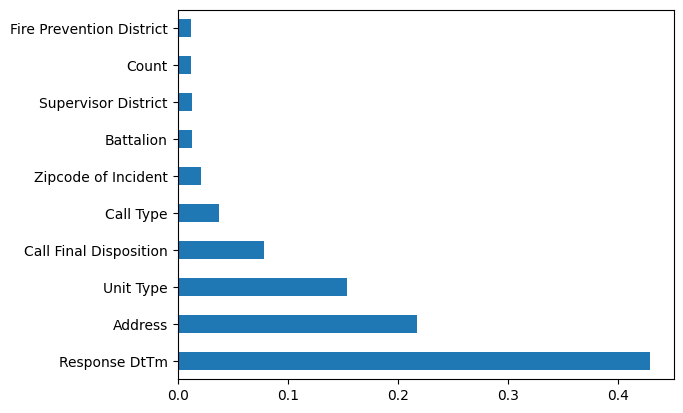

In [25]:
from sklearn.ensemble import ExtraTreesClassifier
import matplotlib.pyplot as plt
model = ExtraTreesClassifier()
model.fit(Dispatches,y)
print(model.feature_importances_) #use inbuilt class feature_importances of tree based classifiers
#plot graph of feature importances for better visualization
feat_importances = pd.Series(model.feature_importances_, index=Dispatches.columns)
feat_importances.nlargest(10).plot(kind='barh')
plt.show()

### So time whe call was recieved and adress are most important features. Probably time affects if streets are busy and adress - if response units are stationed nearby. Results are completely different from K-means

### Looking for patterns in outliers

In [26]:
from sklearn.neighbors import LocalOutlierFactor

clf = LocalOutlierFactor(n_neighbors=20, contamination=0.1)
y_pred = clf.fit_predict(Dispatches)


In [27]:
y_pred[y_pred==-1].sum()/y_pred[y_pred!=-1].sum()

np.float64(-0.11111337351360157)

### around 10% is considered notmal for outlier count

In [29]:
n_cols = len(Dispatches.columns)
n_cols

11

### Outputing scatterplots for all pairs of features to see if there are any distinct clusters for outliers

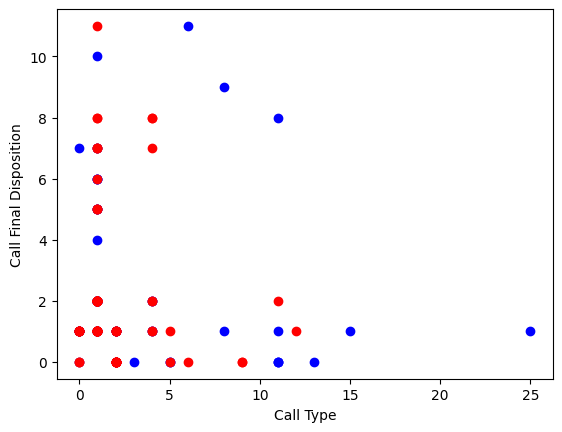

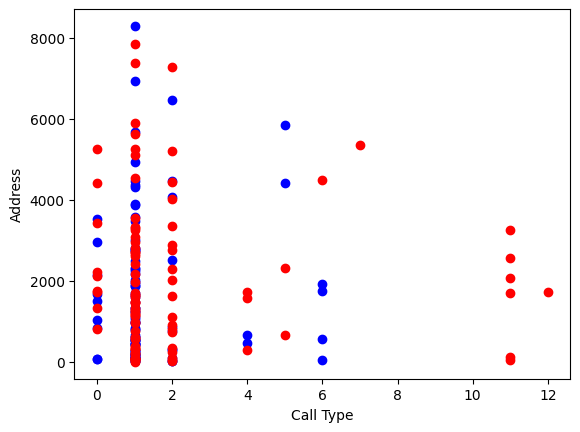

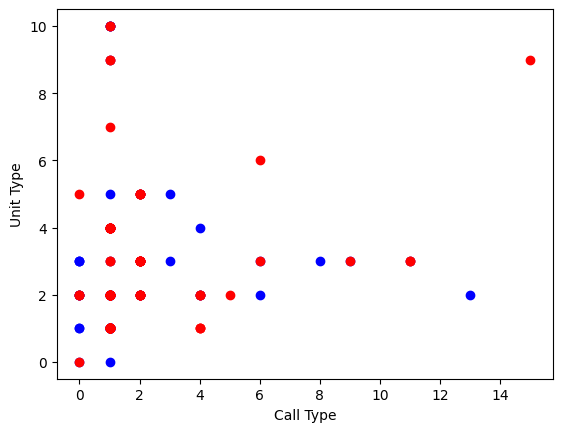

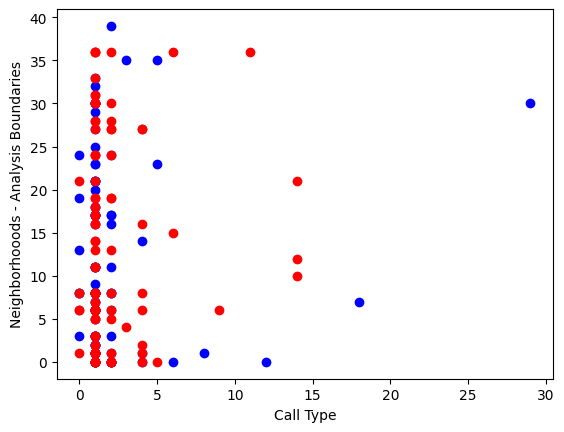

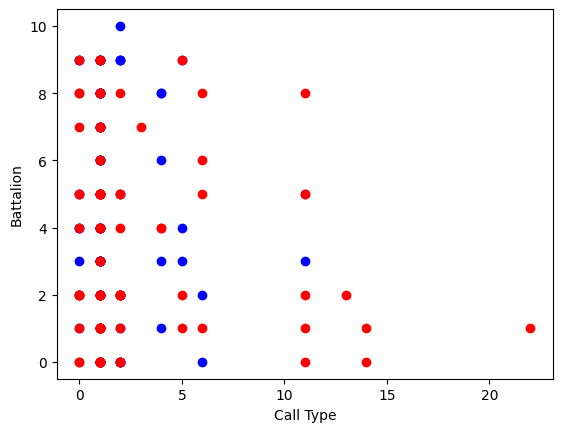

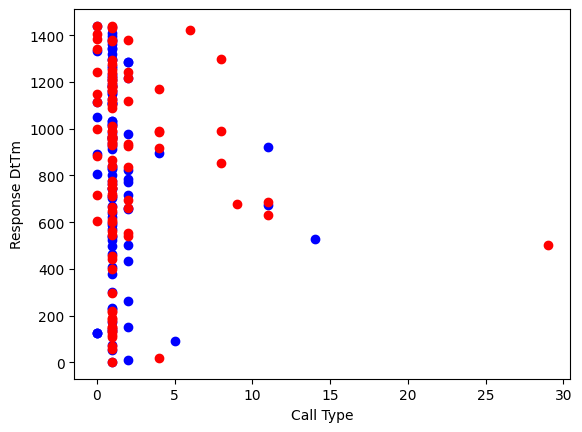

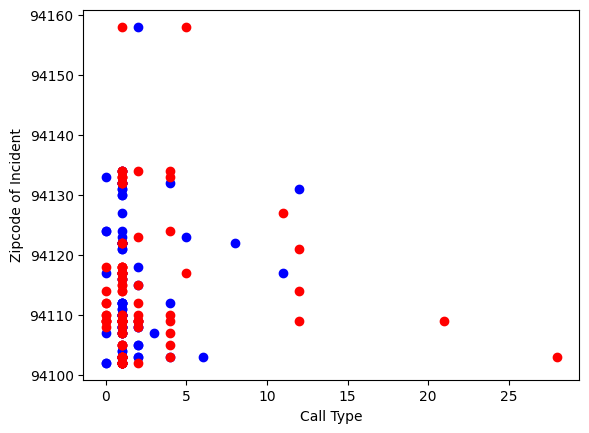

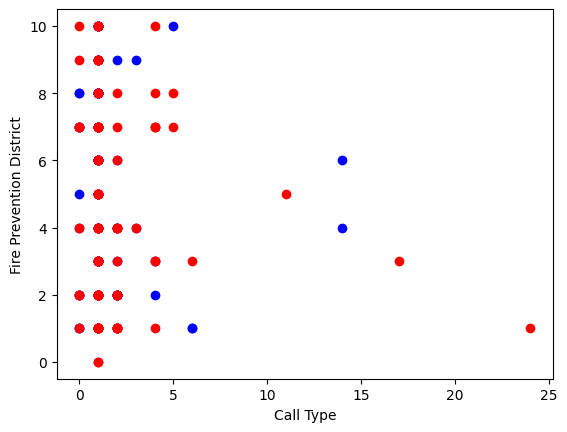

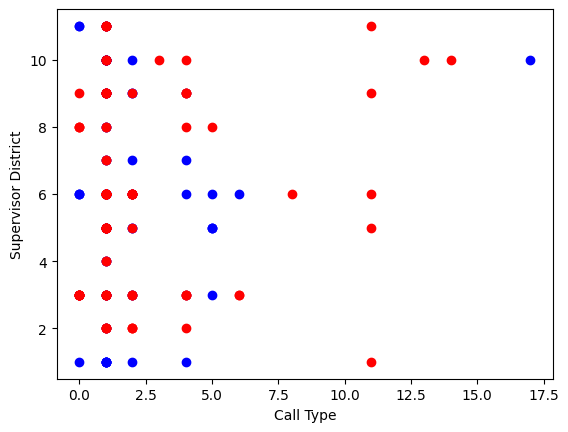

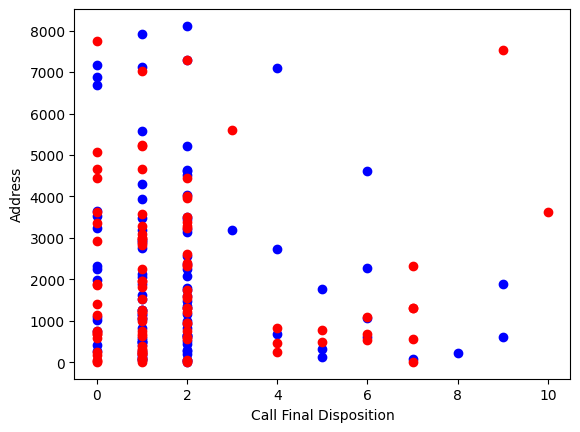

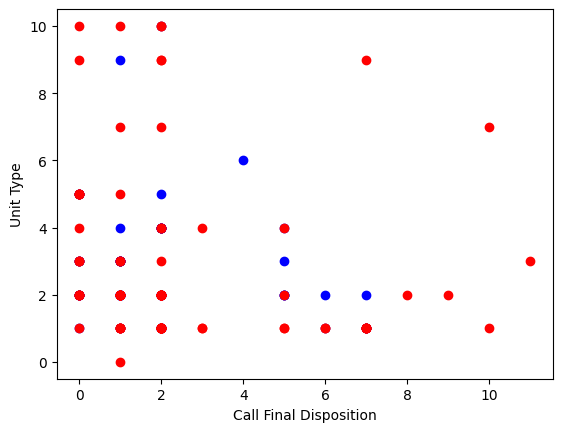

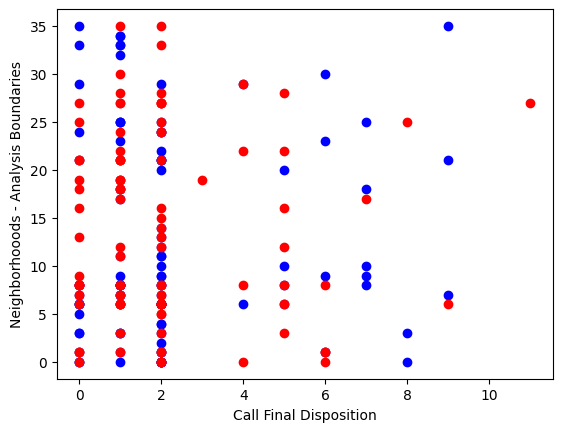

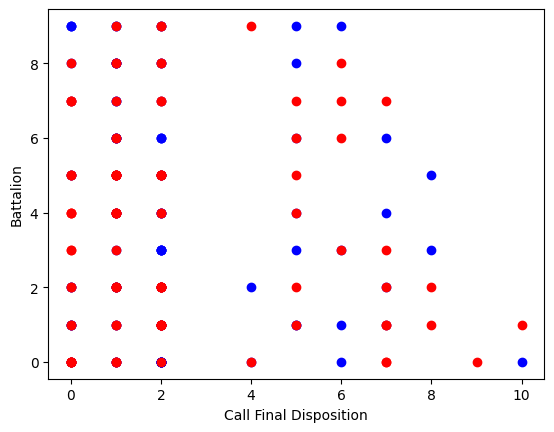

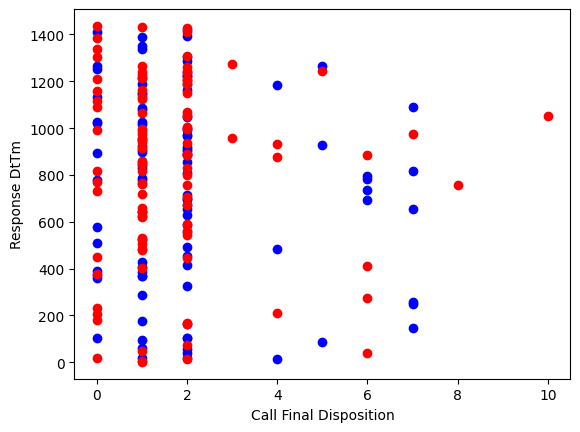

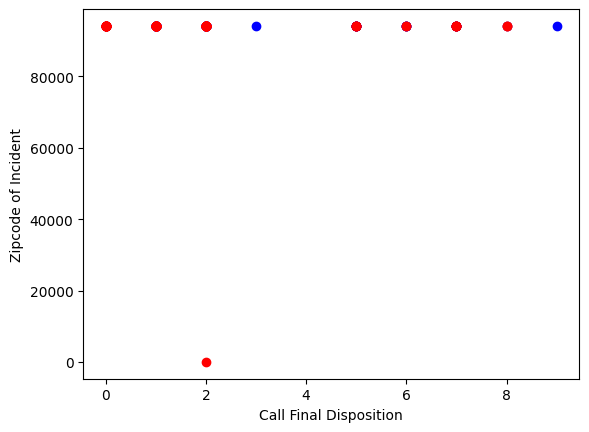

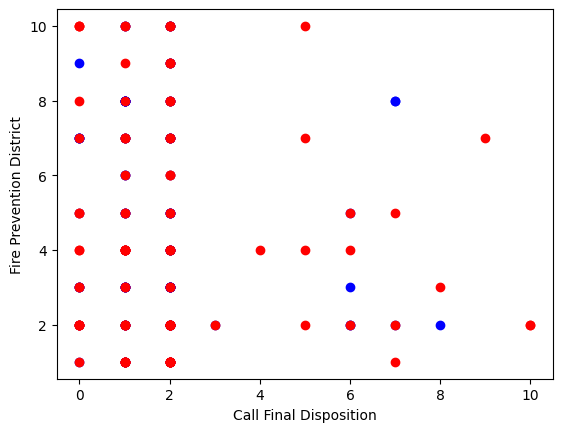

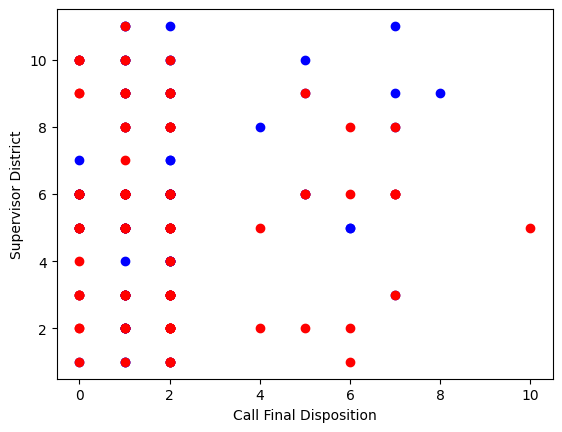

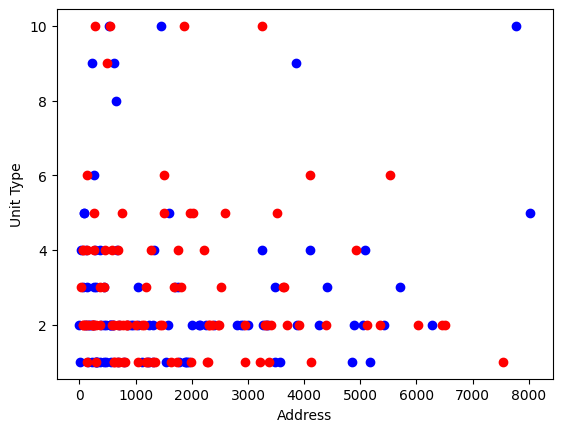

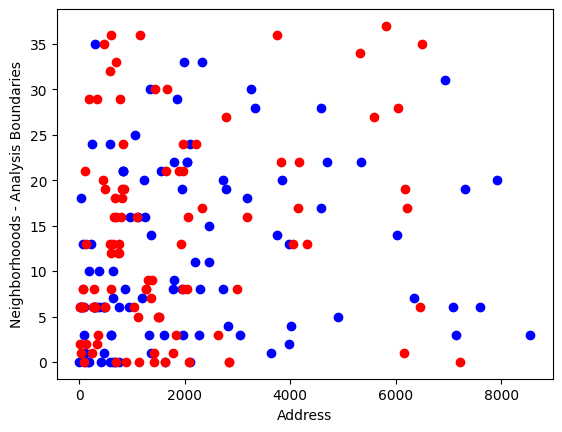

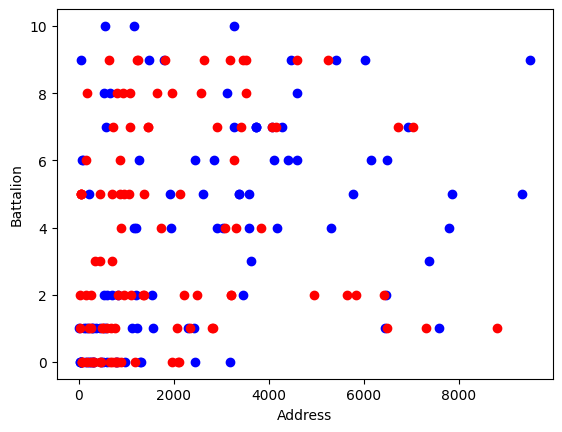

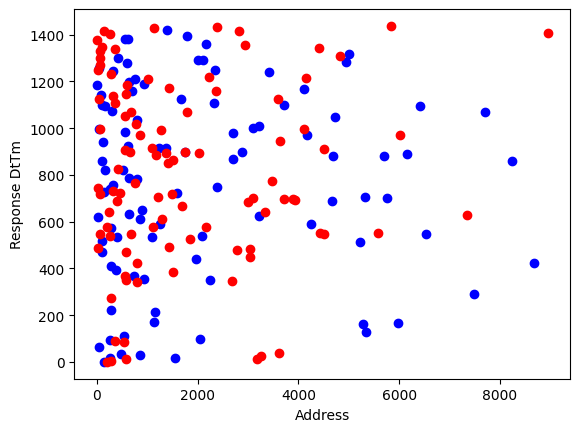

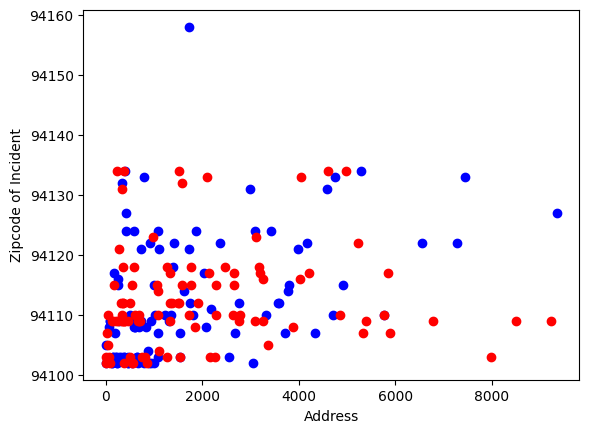

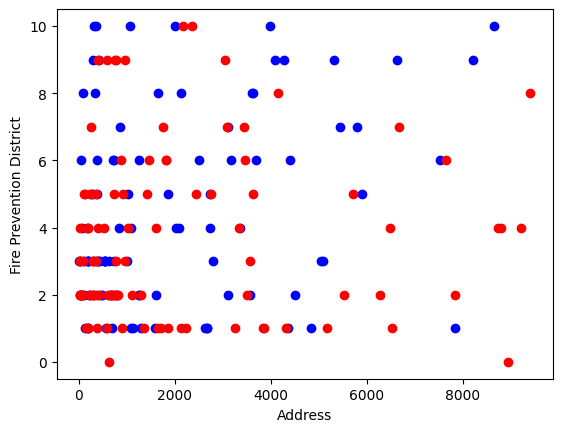

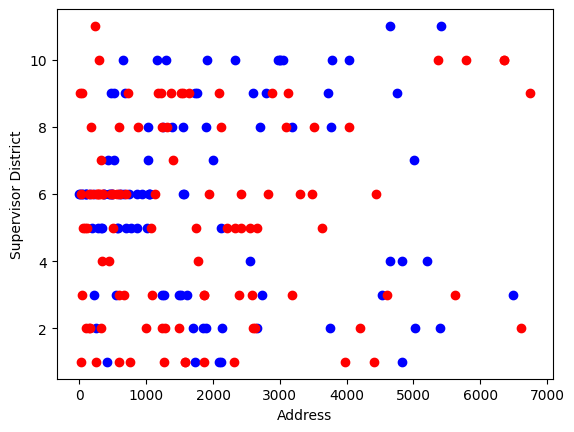

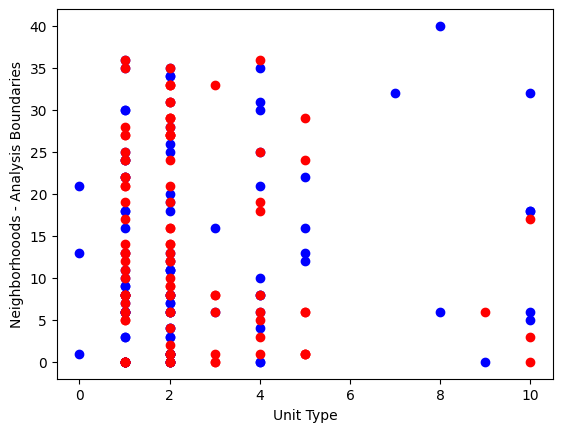

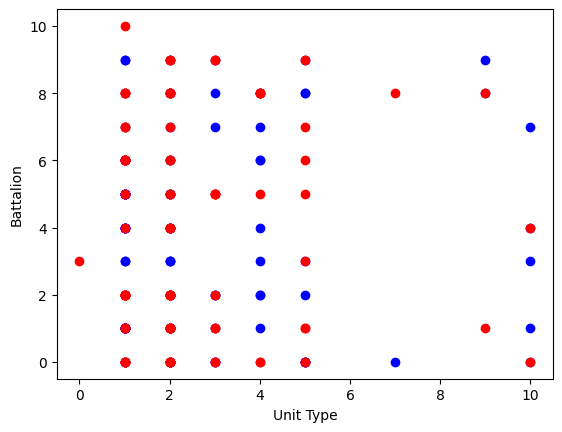

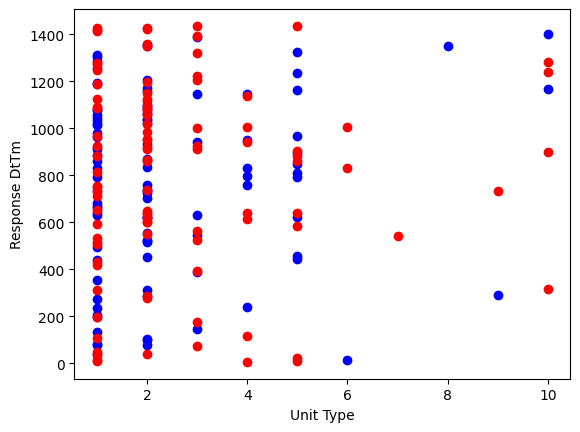

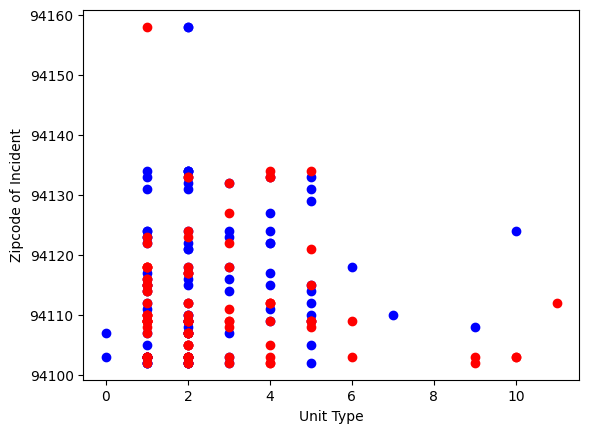

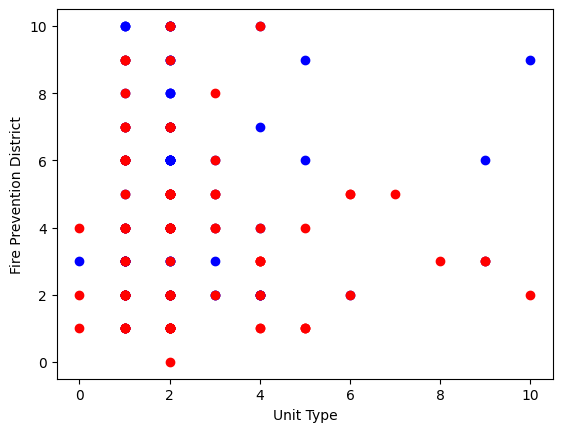

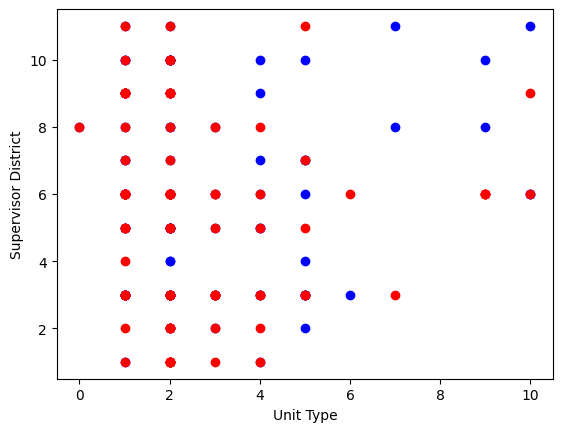

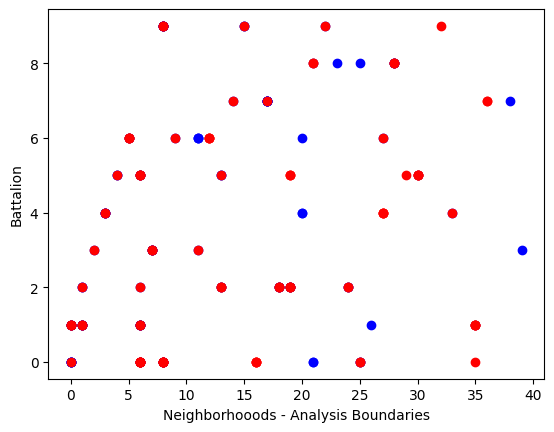

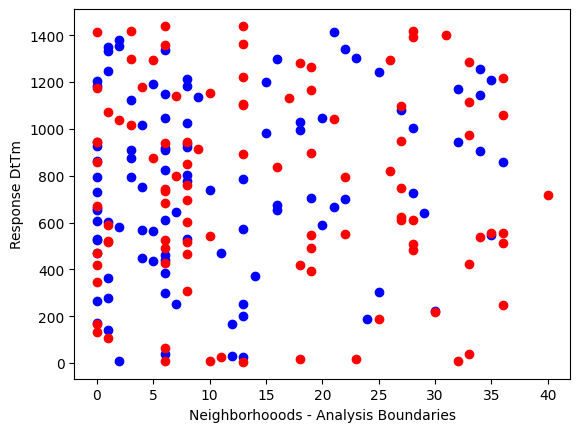

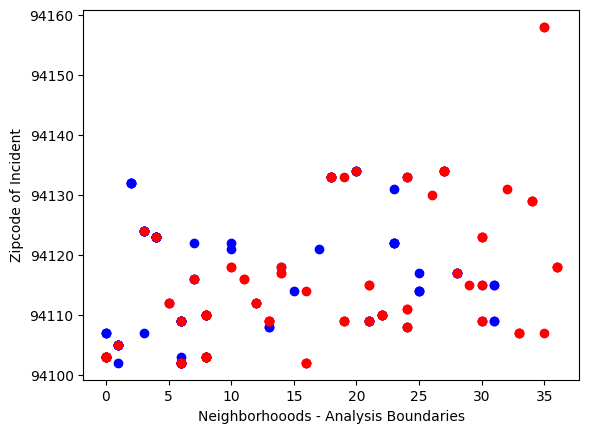

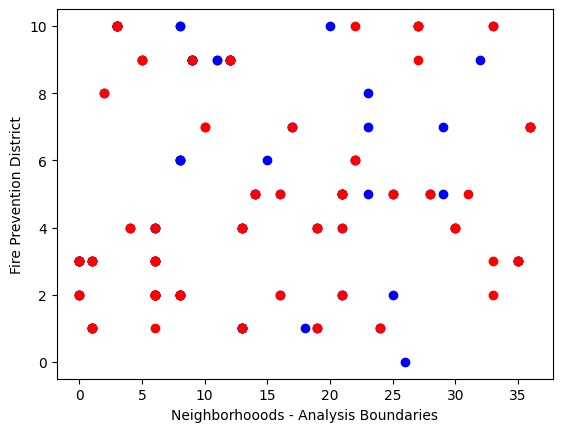

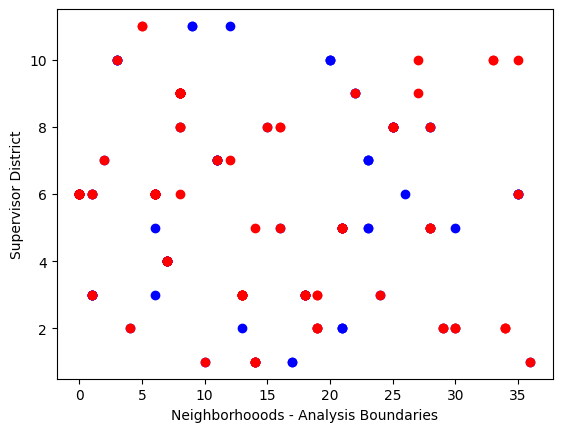

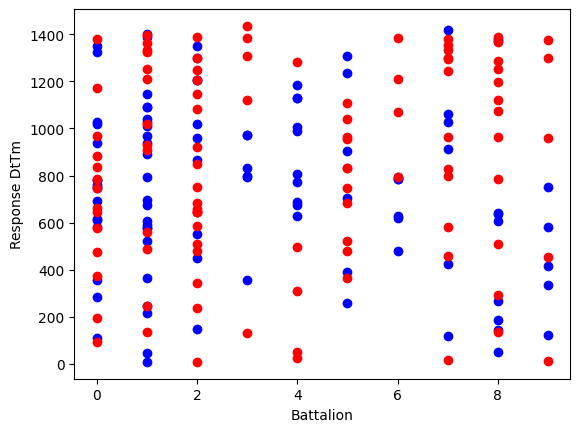

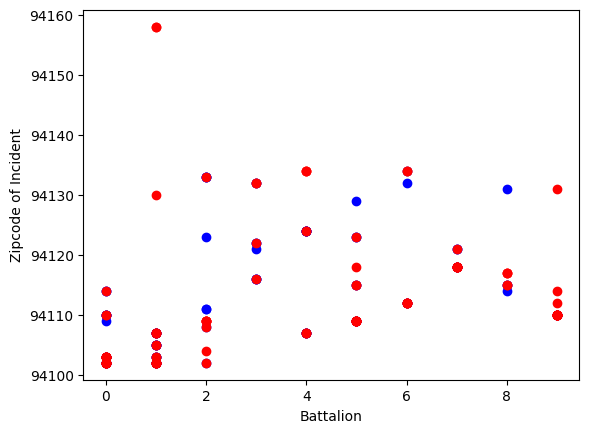

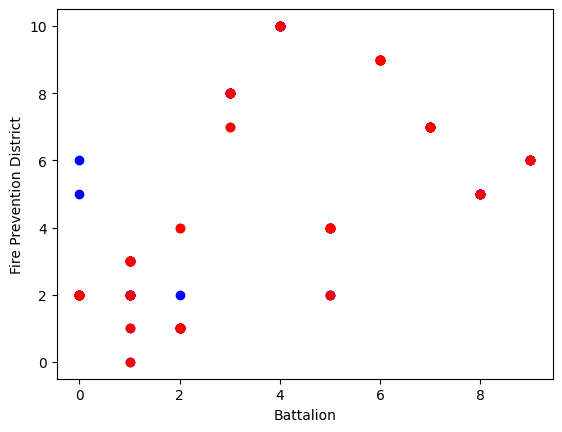

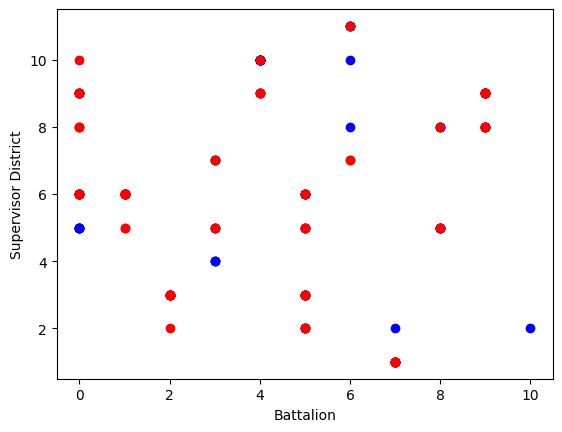

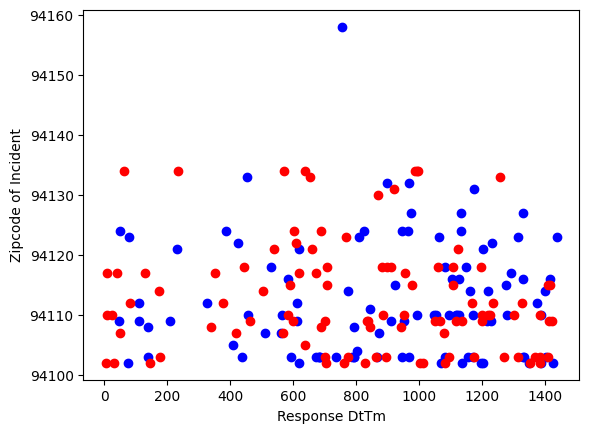

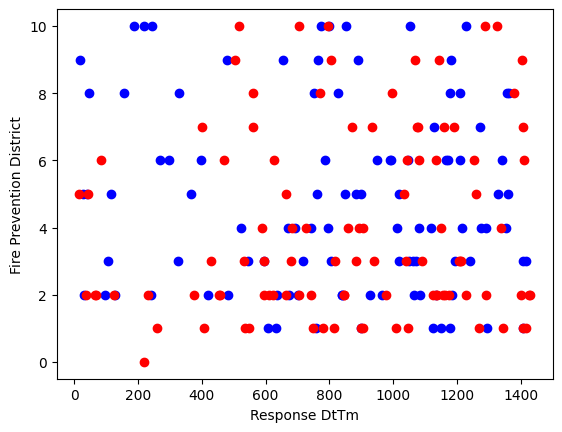

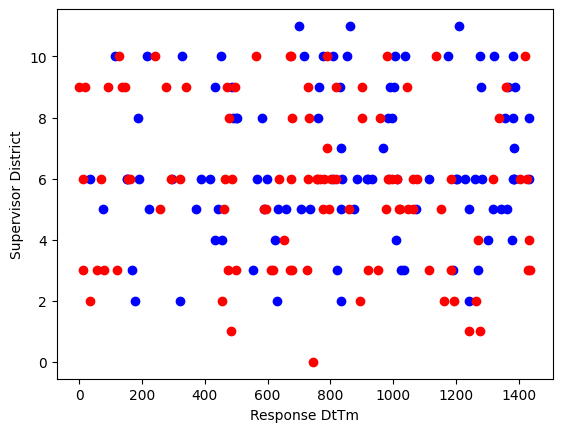

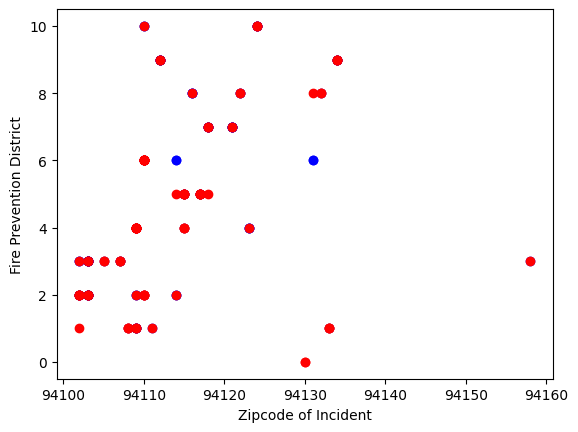

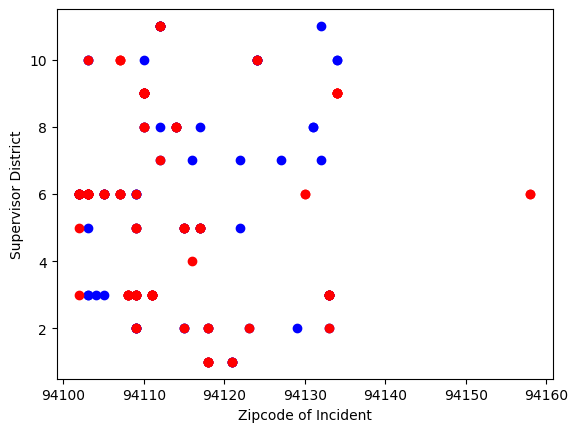

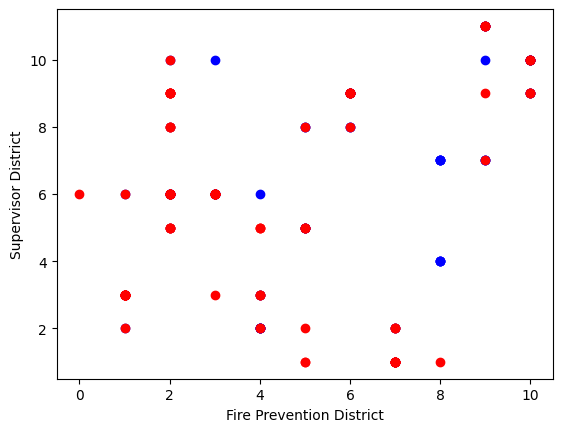

In [30]:
for col in range(0,n_cols-1):
    for col2 in range(col+1,n_cols-1):
        col_name1 = Dispatches.columns[col]
        col_name2 = Dispatches.columns[col2]
        fig, ax = plt.subplots()
        subsample = Dispatches[y_pred!=-1].sample(100)
        ax.scatter(subsample[col_name1], subsample[col_name2], c='blue')

        subsample = Dispatches[y_pred==-1].sample(100)
        ax.scatter(subsample[col_name1], subsample[col_name2], c='red')

        ax.set_xlabel(col_name1)
        ax.set_ylabel(col_name2)
        plt.show()
    

### No obvious patterns, maybe more outliers for empty values which used to be nan but no other dependacies